# CS03 - Machine Learning (Sprint 3)
## Prevenção de Sinistros em Equipamentos Agrícolas (Projeto SOMPO)

**Equipe Oasis:**
* Adalberto Alves Cruz | RM: 574115
* Bruno Henrique Ferreira Ambrosio | RM: 571218
* Gustavo da Silva Nascimento | RM: 570821
* Lucas Maximo dos Santos | RM: 569714
* Renan de Assis Rodrigues | RM: 574049
* Tiago Thomaz Cesaro | RM: 569374

---
**Objetivo do Notebook:**
Este notebook apresenta o desenvolvimento do entregável da Sprint 3. Nosso objetivo é construir, validar e otimizar modelos de Machine Learning de Classificação (Random Forest e KNN) para prever o risco de sinistros em máquinas agrícolas. A solução visa apoiar as decisões estratégicas da SOMPO Seguros, reduzindo prejuízos financeiros e operacionais causados por quebras e acidentes.

## Passo 1: Criação da Base de Dados (SOMPO)

Nesta etapa, simulamos os dados reais de operação das máquinas agrícolas. Criamos variáveis de negócio importantes como temperatura, horas de uso contínuo, tipo de terreno e proximidade de água.

Também definimos a nossa variável alvo (`risco_sinistro`) usando uma função baseada em regras operacionais, adicionando um fator de probabilidade (ruído) para simular imprevistos do mundo real e evitar que o modelo sofra de *overfitting* (decorar os dados).

In [16]:
import pandas as pd
import numpy as np
import random

np.random.seed(42)
random.seed(42)

n_registros = 1000

dados = {
    'equipamento': np.random.choice(['Trator', 'Colheitadeira', 'Pulverizador'], n_registros),
    'temperatura_motor': np.round(np.random.normal(75, 12, n_registros), 1),
    'horas_uso_continuo': np.round(np.random.uniform(1, 12, n_registros), 1),
    'operacao': np.random.choice(['Campo', 'Transporte'], n_registros, p=[0.7, 0.3]),
    'terreno_irregular': np.random.choice(['Sim', 'Nao'], n_registros, p=[0.4, 0.6]),
    'proximidade_agua': np.random.choice(['Sim', 'Nao'], n_registros, p=[0.15, 0.85])
}

df_sompo = pd.DataFrame(dados)

def calcular_risco(linha):
    chance_de_sinistro = 0.05

    if linha['temperatura_motor'] > 85:
        chance_de_sinistro += 0.50

    if linha['proximidade_agua'] == 'Sim' and linha['terreno_irregular'] == 'Sim':
        chance_de_sinistro += 0.35

    if linha['horas_uso_continuo'] > 8:
        chance_de_sinistro += 0.15

    if random.random() < chance_de_sinistro:
        return 1
    else:
        return 0

df_sompo['risco_sinistro'] = df_sompo.apply(calcular_risco, axis=1)

print(f"Dataset criado com {df_sompo.shape[0]} linhas e {df_sompo.shape[1]} colunas.")
print(f"Total de sinistros simulados: {df_sompo['risco_sinistro'].sum()}")
df_sompo.head()

Dataset criado com 1000 linhas e 7 colunas.
Total de sinistros simulados: 217


,equipamento,temperatura_motor,horas_uso_continuo,operacao,terreno_irregular,proximidade_agua,risco_sinistro
0,Pulverizador,75.6,9.7,Transporte,Sim,Nao,0
1,Trator,65.0,6.7,Campo,Sim,Nao,1
2,Pulverizador,78.2,5.8,Campo,Nao,Nao,0
3,Pulverizador,74.4,2.6,Campo,Nao,Nao,0
4,Trator,72.1,4.6,Campo,Sim,Nao,0


## Passo 2: Preparação dos Dados (OHE, Holdout e Scaling)

Para que os modelos matemáticos consigam ler nossa base, aplicamos três técnicas de preparação obrigatórias:
*   **One-Hot Encoding (OHE):** Transformamos variáveis de texto (ex: 'Trator', 'Transporte') em colunas binárias (0 e 1).
*   **Holdout (Treino/Teste):** Dividimos o dataset em 80% para ensinar os algoritmos e 20% para testá-los em dados não vistos.
*   **Scaling (Padronização):** Usamos o `StandardScaler` nas variáveis numéricas para garantir que a diferença de escala (ex: temperatura nos 80, horas nos 10) não distorça os cálculos matemáticos.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


colunas_categoricas = ['equipamento', 'operacao', 'terreno_irregular', 'proximidade_agua']
df_encoded = pd.get_dummies(df_sompo, columns=colunas_categoricas, drop_first=True)


X = df_encoded.drop('risco_sinistro', axis=1)
y = df_encoded['risco_sinistro']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
colunas_numericas = ['temperatura_motor', 'horas_uso_continuo']

X_train[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

print("--- PREPARAÇÃO CONCLUÍDA ---")
print(f"Colunas após OHE: {list(X.columns)}")
print(f"Linhas para Treino: {X_train.shape[0]}")
print(f"Linhas para Teste: {X_test.shape[0]}")
X_train.head()

--- PREPARAÇÃO CONCLUÍDA ---
Colunas após OHE: ['temperatura_motor', 'horas_uso_continuo', 'equipamento_Pulverizador', 'equipamento_Trator', 'operacao_Transporte', 'terreno_irregular_Sim', 'proximidade_agua_Sim']
Linhas para Treino: 800
Linhas para Teste: 200


,temperatura_motor,horas_uso_continuo,equipamento_Pulverizador,equipamento_Trator,operacao_Transporte,terreno_irregular_Sim,proximidade_agua_Sim
167,-0.870839,-1.021932,False,True,False,False,False
555,-1.872138,-0.308189,False,False,True,False,False
761,1.209446,1.057231,False,True,True,False,False
981,1.243974,1.367554,False,True,False,True,False
522,-0.335662,-0.370254,False,False,False,True,False


##Passo 3: Treinamento e Validação dos Modelos

Atendendo ao requisito da Sprint, treinamos dois algoritmos distintos de classificação para prever se a máquina sofrerá sinistro:

**Random Forest**: modelo de ensemble baseado em múltiplas árvores de decisão.

**KNN (K-Nearest Neighbors)**: classifica com base na distância aos vizinhos mais próximos no espaço de features.

Avaliamos os dois usando Accuracy, Precision, Recall, F1-Score e AUC no conjunto de teste (holdout).

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("--- MODELO 1: CLASSIFICAÇÃO (Random Forest) ---")
print("Objetivo: Prever se a máquina sofrerá sinistro (0 ou 1)\n")

rf_class = RandomForestClassifier(random_state=42)
rf_class.fit(X_train, y_train)

y_pred_class = rf_class.predict(X_test)
y_prob_class = rf_class.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_class))
print(f"AUC (Área sob a curva): {roc_auc_score(y_test, y_prob_class):.3f}\n")
print("-" * 50)

print("\n--- MODELO 2: CLASSIFICAÇÃO (KNN) ---")
print("Objetivo: Prever se a máquina sofrerá sinistro (0 ou 1), usando distância entre vizinhos\n")

knn_class = KNeighborsClassifier(n_neighbors=5)
knn_class.fit(X_train, y_train)

y_pred_knn = knn_class.predict(X_test)
y_prob_knn = knn_class.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_knn))
print(f"AUC (Área sob a curva): {roc_auc_score(y_test, y_prob_knn):.3f}")

--- MODELO 1: CLASSIFICAÇÃO (Random Forest) ---
Objetivo: Prever se a máquina sofrerá sinistro (0 ou 1)

              precision    recall  f1-score   support

           0       0.85      0.90      0.87       157
           1       0.53      0.40      0.45        43

    accuracy                           0.80       200
   macro avg       0.69      0.65      0.66       200
weighted avg       0.78      0.80      0.78       200

AUC (Área sob a curva): 0.801

--------------------------------------------------

--- MODELO 2: CLASSIFICAÇÃO (KNN) ---
Objetivo: Prever se a máquina sofrerá sinistro (0 ou 1), usando distância entre vizinhos

              precision    recall  f1-score   support

           0       0.84      0.94      0.89       157
           1       0.62      0.35      0.45        43

    accuracy                           0.81       200
   macro avg       0.73      0.65      0.67       200
weighted avg       0.79      0.81      0.79       200

AUC (Área sob a curva): 0.751


#Passo 4: Tuning Básico (Ajuste de Hiperparâmetros)

Para extrair a melhor performance possível dos dois modelos, aplicamos **GridSearchCV** com validação cruzada (cv=5) em cada um: no **Random Forest** testamos número de árvores, profundidade máxima e regras de divisão; no KNN testamos o valor de k **(n_neighbors)** e o tipo de ponderação **(weights)**. Depois reavaliamos os dois modelos tunados no conjunto de teste (holdout) para medir o ganho real e comparar o desempenho entre eles.

--- PASSO 4: TUNING BÁSICO ---

[Random Forest] Melhores hiperparâmetros: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
[Random Forest] Melhor acurácia média (CV no treino): 0.820

>>> Random Forest TUNADO avaliado no conjunto de TESTE (holdout):
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       157
           1       0.59      0.40      0.47        43

    accuracy                           0.81       200
   macro avg       0.72      0.66      0.68       200
weighted avg       0.79      0.81      0.80       200

AUC: 0.819

--------------------------------------------------

[KNN] Melhores hiperparâmetros: {'n_neighbors': 15, 'weights': 'uniform'}
[KNN] Melhor acurácia média (CV no treino): 0.810

>>> KNN TUNADO avaliado no conjunto de TESTE (holdout):
              precision    recall  f1-score   support

           0       0.84      0.96      0.89       157
           1       0.67      0.33      0.44        43



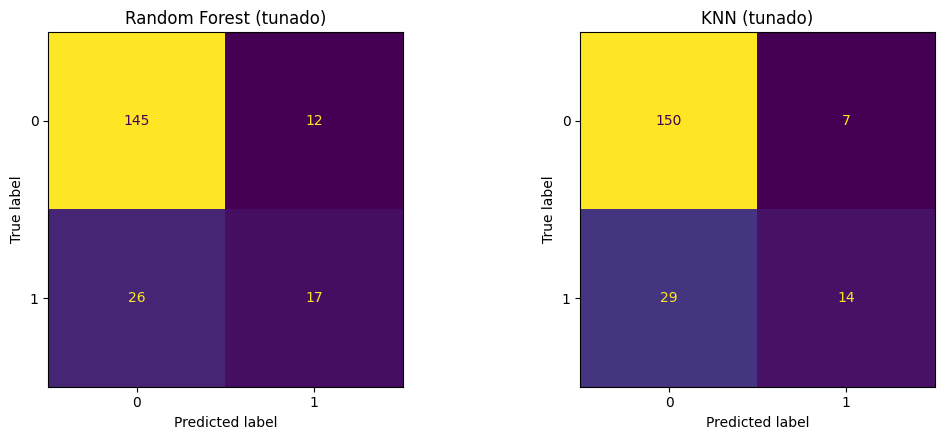


--- COMPARATIVO FINAL ---
Random Forest -> Accuracy: 0.810 | AUC: 0.819
KNN            -> Accuracy: 0.820 | AUC: 0.782


In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

print("--- PASSO 4: TUNING BÁSICO ---\n")


parametros_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                        param_grid=parametros_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"[Random Forest] Melhores hiperparâmetros: {grid_rf.best_params_}")
print(f"[Random Forest] Melhor acurácia média (CV no treino): {grid_rf.best_score_:.3f}")

melhor_rf = grid_rf.best_estimator_
y_pred_rf_tuned = melhor_rf.predict(X_test)
y_prob_rf_tuned = melhor_rf.predict_proba(X_test)[:, 1]

print("\n>>> Random Forest TUNADO avaliado no conjunto de TESTE (holdout):")
print(classification_report(y_test, y_pred_rf_tuned))
print(f"AUC: {roc_auc_score(y_test, y_prob_rf_tuned):.3f}\n")
print("-" * 50)


parametros_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(estimator=KNeighborsClassifier(),
                         param_grid=parametros_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)

print(f"\n[KNN] Melhores hiperparâmetros: {grid_knn.best_params_}")
print(f"[KNN] Melhor acurácia média (CV no treino): {grid_knn.best_score_:.3f}")

melhor_knn = grid_knn.best_estimator_
y_pred_knn_tuned = melhor_knn.predict(X_test)
y_prob_knn_tuned = melhor_knn.predict_proba(X_test)[:, 1]

print("\n>>> KNN TUNADO avaliado no conjunto de TESTE (holdout):")
print(classification_report(y_test, y_pred_knn_tuned))
print(f"AUC: {roc_auc_score(y_test, y_prob_knn_tuned):.3f}")


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf_tuned)).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Random Forest (tunado)')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn_tuned)).plot(ax=axes[1], colorbar=False)
axes[1].set_title('KNN (tunado)')
plt.tight_layout()
plt.show()


print("\n--- COMPARATIVO FINAL ---")
print(f"Random Forest -> Accuracy: {(y_pred_rf_tuned==y_test).mean():.3f} | AUC: {roc_auc_score(y_test, y_prob_rf_tuned):.3f}")
print(f"KNN            -> Accuracy: {(y_pred_knn_tuned==y_test).mean():.3f} | AUC: {roc_auc_score(y_test, y_prob_knn_tuned):.3f}")

# Passo 5: Interpretação (O que causa mais risco?)

Com o modelo devidamente validado e otimizado, usamos a função de `Feature Importance` do Random Forest para "abrir a caixa preta" do algoritmo.

O gráfico abaixo classifica matematicamente quais variáveis têm o maior peso na ocorrência de sinistros, entregando para a SOMPO um *insight* claro e acionável de onde focar suas políticas de prevenção.

--- PASSO 5: INTERPRETAÇÃO (Feature Importance) ---


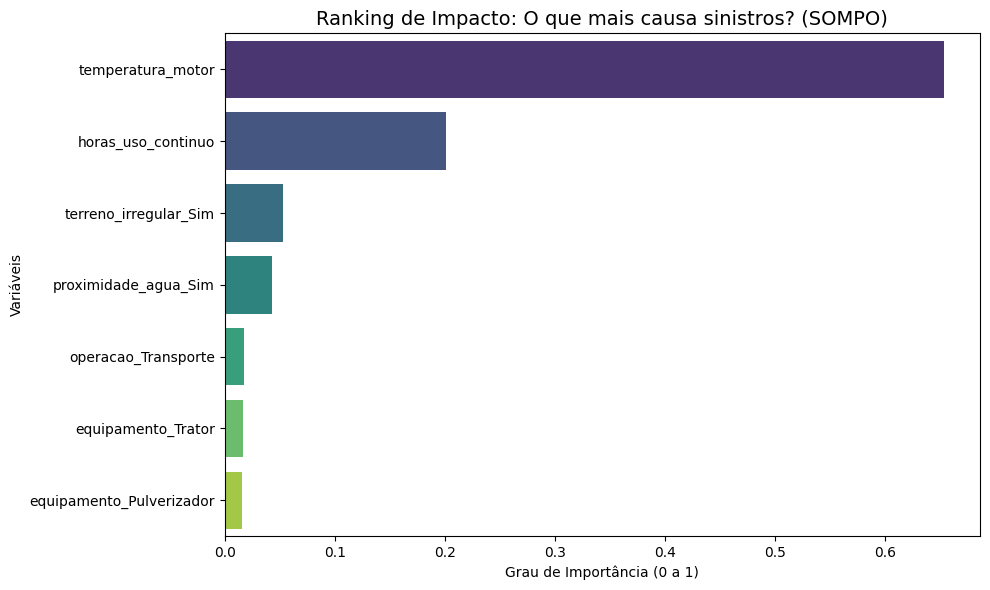


RESPOSTA PARA A BANCA:
Com base no modelo tunado, as variáveis que mais impactam o risco são:
- temperatura_motor (65.3%)
- horas_uso_continuo (20.1%)
- terreno_irregular_Sim (5.3%)


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- PASSO 5: INTERPRETAÇÃO (Feature Importance) ---")


melhor_rf = grid_rf.best_estimator_


importancias = melhor_rf.feature_importances_
features = X_train.columns


df_importancia = pd.DataFrame({'Feature': features, 'Importância': importancias})
df_importancia = df_importancia.sort_values(by='Importância', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Feature', hue='Feature', data=df_importancia, palette='viridis', legend=False)
plt.title('Ranking de Impacto: O que mais causa sinistros? (SOMPO)', fontsize=14)
plt.xlabel('Grau de Importância (0 a 1)')
plt.ylabel('Variáveis')
plt.tight_layout()
plt.show()


print("\nRESPOSTA PARA A BANCA:")
print("Com base no modelo tunado, as variáveis que mais impactam o risco são:")
for idx, row in df_importancia.head(3).iterrows():
    print(f"- {row['Feature']} ({row['Importância']*100:.1f}%)")

## Conclusão

A análise desenvolvida nesta Sprint comprovou que é plenamente possível utilizar inteligência artificial para antecipar e mitigar riscos na operação de maquinários agrícolas.

**Principais Descobertas:**

1. **Comparação entre modelos:** Random Forest e KNN apresentaram acurácia semelhante no teste (0.81 vs. 0.82), mas o Random Forest se mostrou a escolha mais adequada para o negócio por apresentar recall superior na classe de sinistro (0.40 vs. 0.33) e maior AUC (0.819 vs. 0.782). Em um cenário de seguros, deixar de prever um sinistro real (falso negativo) é mais custoso do que gerar um alerta falso, o que torna essa métrica mais relevante que a acurácia isolada.

2. **Limitação atual do recall:** apesar da acurácia geral ser boa, o modelo ainda erra a maioria dos casos positivos (recall de 0.40 na classe de sinistro), evidenciando que a base simulada - com apenas ~22% de casos de sinistro - é desbalanceada e limita a capacidade de generalização do modelo para a classe minoritária. Técnicas de balanceamento (ex: SMOTE, ajuste de threshold) e mais dados reais são próximos passos recomendados para elevar essa métrica.

3. **Fatores Críticos de Risco:** A interpretação do modelo (Feature Importance do Random Forest tunado) revelou que a **temperatura do motor (65.3%)** e as **horas de uso contínuo (20.1%)** são os maiores causadores de sinistros, reforçando a importância de monitoramento contínuo via sensores IoT nas máquinas como principal frente de prevenção para a SOMPO.